In [1]:
from sklearn.datasets import make_regression
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [19]:
X, y = make_regression(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_targets=1,
    noise=20,
    random_state=42
)

<p>make_regression(n_samples=1000, n_features=2, n_informative=2, n_targets=1, noise=20) creates 1000 samples with 2 useful input features and 1 continuous target, with substantial random noise added to the target.</p>

In [20]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [21]:
df.head()

,feature1,feature2,target
0,-0.167118,0.146714,-24.158869
1,-0.020902,0.117327,-25.279737
2,0.150419,0.364961,27.018156
3,0.555604,0.089581,-9.887410
4,0.058209,-1.142970,-23.216046


In [22]:
df.shape

(1000, 3)

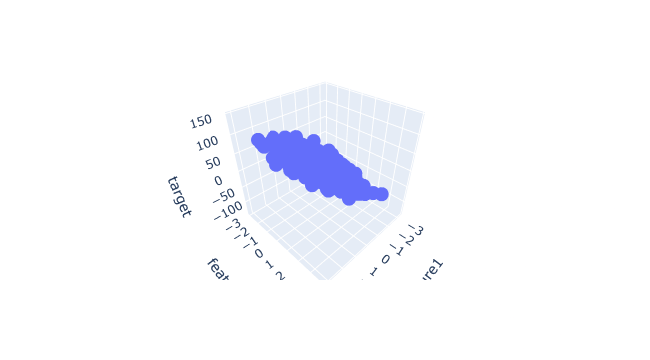

In [23]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

<h2>Training the Data</h2>

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=3)

In [33]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
y_pred=lr.predict(X_test)

In [35]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 15.937616060737842
MSE 417.00109144797943
R2 score 0.7761722652282226


<h2>Visualising on more data</h2>

In [38]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)
z = z_final

<p>
<b>x = np.linspace(-5, 5, 10)</b>

Create values for feature 1 — Generate a range of possible values that will be used for the X-axis.
    
<b>y = np.linspace(-5, 5, 10)</b>

Create values for feature 2 — Generate a range of possible values that will be used for the Y-axis.

<b>xGrid, yGrid = np.meshgrid(x, y)</b>

Create a grid — Combine the feature 1 and feature 2 values to create many possible input combinations.

<b>final = np.vstack((xGrid.ravel().reshape(1,100),
                   yGrid.ravel().reshape(1,100))).T</b>

Prepare the input points — Arrange all those combinations into the format required by the trained model.

<b>z_final = lr.predict(final).reshape(10,10)</b>

Predict the target values — Give all the input combinations to the trained Linear Regression model to get predicted target values. And then we reshape the 100 predictions into the same 10 × 10 structure.
</p>

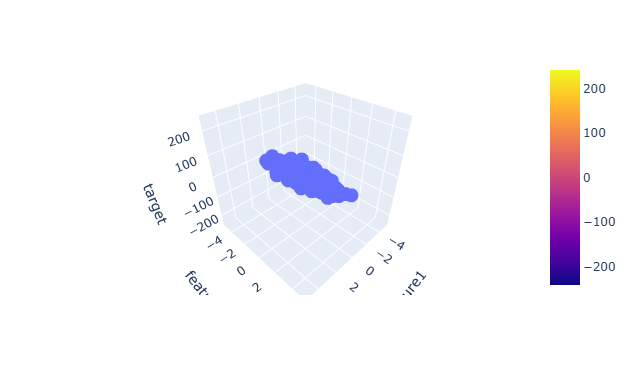

In [42]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

#This tells to Take these feature1 values, these feature2 values,
#and these predicted target values, and create a surface.

fig.show()

In [43]:
lr.coef_
#gives b1 and b2

array([40.99470601,  7.3204955 ])

In [44]:
lr.intercept_
#give b0

np.float64(-0.11282052233446027)